In [1]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift
from utility.my_colors import palette_light, pink

from processing.remove_spikes import remove_spikes
from processing.fit_continuum import fit_continuum
from processing.quality_cuts import quality_cuts
from processing.make_bal_mask import make_bal_mask
from processing.fit_gaussians import fit_single_gaussian, fit_two_gaussians, ftest_which_gaussian
from processing.measure_line import measure_line

from sparcl.client import SparclClient
from dl import queryClient as qc
from astropy.table import Table
from astropy.convolution import convolve, Gaussian1DKernel
from scipy.interpolate import interp1d

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings

hamann_fits_path = "data/local/ERQs_core_all_MNRAS.fits"
search_log_path = "data/local/hamann-objects-desi-search-log.json"
hamann_desi_spectra_path = "data/local/hamann_desi_spectra.json"

### load data

In [2]:
hamann_data = Table.read("data/local/ERQs_core_all_MNRAS.fits").to_pandas() #pd.read_csv(hamann_erq_path,index_col=0)

hamann_data["sdss_name"] = hamann_data["sdss_name"].astype("string")

match_df = pd.read_json(search_log_path)
match_df = match_df[["SDSS_id","best_match_id"]].copy()
match_df["SDSS_id"] = match_df["SDSS_id"].str[1:]

match_df = match_df.rename(columns={"best_match_id":"targetid", "SDSS_id":"sdss_name"})

hamann_erq = hamann_data.merge(match_df,on="sdss_name",how="left")

hamann_erq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 47 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sdss_name    97 non-null     object 
 1   Plate        97 non-null     int32  
 2   MJD          97 non-null     int32  
 3   FiberID      97 non-null     int32  
 4   ThingID      97 non-null     int32  
 5   z_dr12       97 non-null     float64
 6   i            97 non-null     float64
 7   i_err        97 non-null     float64
 8   W3           97 non-null     float64
 9   W3_snr       97 non-null     float64
 10  cc_flags     97 non-null     object 
 11  bal_flag_vi  97 non-null     int32  
 12  f1450        97 non-null     float64
 13  alpha_civ    97 non-null     float64
 14  alpha_nv     97 non-null     float64
 15  alpha_all    97 non-null     float64
 16  alphae_all   97 non-null     float64
 17  alpha_allc   97 non-null     float64
 18  alphae_allc  97 non-null     float64
 19  rew       

In [3]:
# client = SparclClient()

# idxs = [int(x) for x in hamann_erq["targetid"] if x != "Not found"]

# output_fields = ['specid', 'redshift', 'wavelength', 'flux', 'ivar', 'spectype', 'targetid', 'redshift_warning']

# spectra = client.retrieve_by_specid(idxs, dataset_list=["DESI-DR1"], include=output_fields)

# spectra_df = pd.DataFrame(spectra.data[1:])

# spectra_df

### measure lines

In [4]:
# spectra_df.to_json(hamann_desi_spectra_path)

spectra_df = pd.read_json(hamann_desi_spectra_path)

# spectra_df

In [ ]:
def sanity_tests(idx):
    lam = np.array(spectra_df["wavelength"][idx])
    flux = np.array(spectra_df["flux"][idx])
    ivar = np.array(spectra_df["ivar"][idx])
    z = spectra_df["redshift"][idx]

    hamann_stats_for_this_idx = hamann_erq[hamann_erq["targetid"]==str(spectra_df["targetid"][idx])]


    lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)

    flux = convolve(flux, Gaussian1DKernel(1))

    flux_clean, spike_mask = remove_spikes(lam,flux,ivar=ivar)

    result, continuum, window_mask = fit_continuum(lam, flux_clean, ivar=ivar)

    rejected, reason, flags = quality_cuts(lam, flux_clean, continuum, result)
    
    if rejected:
        print(f'SDSS: {hamann_stats_for_this_idx["sdss_name"].squeeze()}, DESI: {hamann_stats_for_this_idx["targetid"].squeeze()}\nRejected because: {reason}')
        plot_spectrum(lam, flux_clean, add_smoothed=False)
        return 

    flux_sub = flux_clean - continuum if not rejected else None
    

    bal_mask = make_bal_mask(lam, flux_sub, ivar=ivar)

    result1, profile1 = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=bal_mask)
    result2, profile2 = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=bal_mask, single_result=result1)

    accept_two, p_val = ftest_which_gaussian(result1, result2)

    plot_mask = (lam >= 1150) & (lam <= 2000)
    continuum_mask = (lam >= 1425) & (lam <= 1810)

    if accept_two:
        line_stats = measure_line(lam, profile2, flux_sub, continuum)
        plot_spectrum(lam[plot_mask], flux_sub[plot_mask], flux_label="continuum subtracted flux", add_smoothed=False, additional_lam=lam[continuum_mask],  additional_flux=profile2[continuum_mask], additional_flux_label="line fit", line_lambda=[1549], line_label=["CIV"], line_width_factor=2)
    else:
        line_stats = measure_line(lam, profile1, flux_sub, continuum)
        plot_spectrum(lam[plot_mask], flux_sub[plot_mask], flux_label="continuum subtracted flux", add_smoothed=False, additional_lam=lam[continuum_mask], additional_flux=profile1[continuum_mask], additional_flux_label="line fit", line_lambda=[1549], line_label=["CIV"], line_width_factor=2)


    query = f'''
        SELECT targetid, civ_1549_flux, civ_1549_flux_ivar
        FROM desi_dr1.agngal
        WHERE (targetid='{spectra_df["targetid"][idx]}')
        '''

    sql_results = qc.query(sql=query, fmt="table")

    out_str = f'''
                SDSS: {hamann_stats_for_this_idx["sdss_name"].squeeze()}, DESI: {hamann_stats_for_this_idx["targetid"].squeeze()}
                FWHM: {round(line_stats["fwhm_kms"],3)} vs {round(hamann_stats_for_this_idx["fwhm"].squeeze(),3)} (Hamann)
                REW: {round(line_stats["ew_aa"],3)} vs {round(hamann_stats_for_this_idx["rew"].squeeze(),3)} (Hamann)
                kt80: {round(line_stats["kt80"],3)} vs {round(hamann_stats_for_this_idx["kt80"].squeeze(),3)} (Hamann)
                flux: {round(line_stats["line_flux"],3)} vs {round(sql_results["civ_1549_flux"].value[0],3)} (DESI)
    '''

    print(out_str)

In [11]:
from data.local.hamann_erq_desi_idxs import valid_idxs
from processing.parameters import CONTINUUM_WINDOWS

print(CONTINUUM_WINDOWS)

[(1425, 1470), (1680, 1710), (1760, 1810)]


---------------------------------------
---------------------------------------


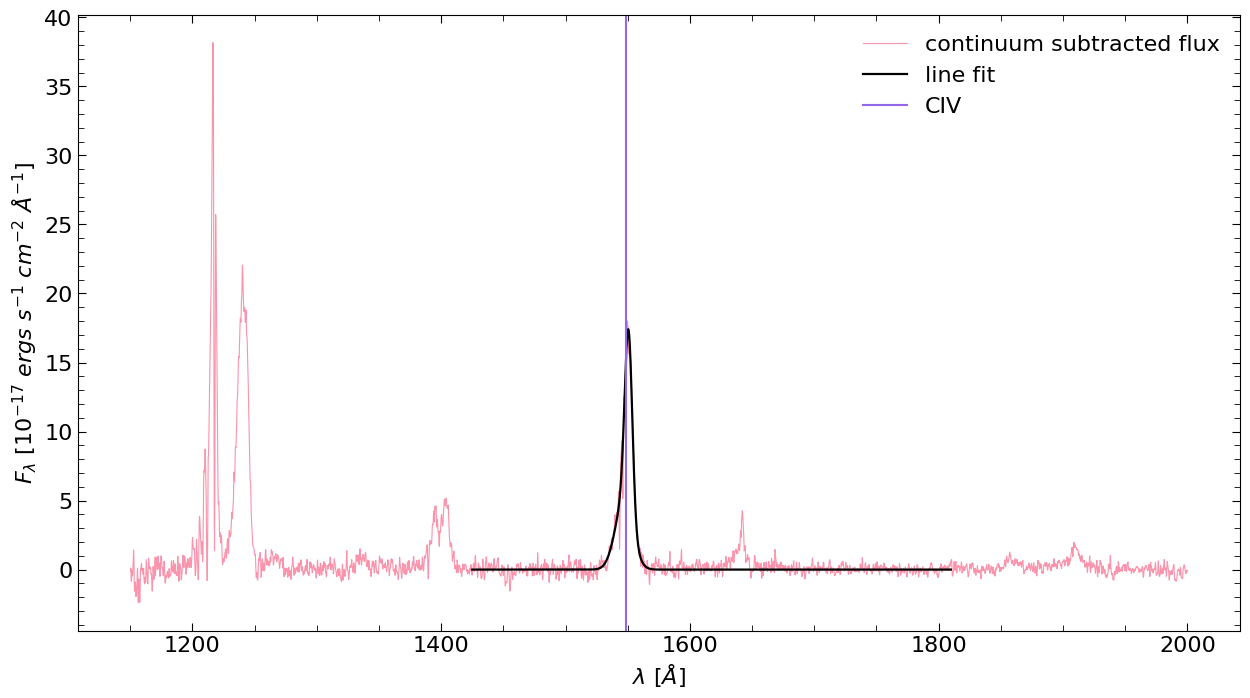


                SDSS: 233636.99+065231.0, DESI: 39627959455190480
                FWHM: 1655.811 vs 1483.559 (Hamann)
                REW: 185.482 vs 128.271 (Hamann)
                kt80: 0.293 vs 0.258 (Hamann)
                flux: 184.995 vs 215.999 (DESI)
    
---------------------------------------
---------------------------------------


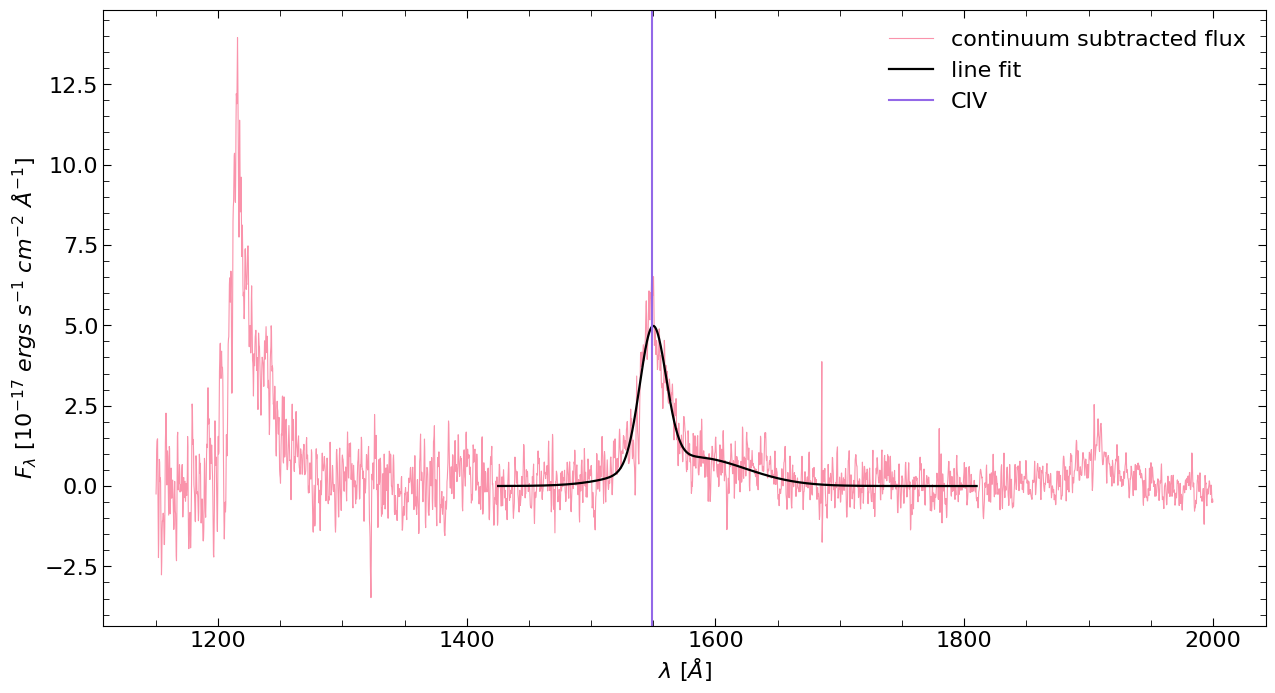


                SDSS: 082649.30+163945.2, DESI: 39628186186682006
                FWHM: 5364.308 vs 5633.199 (Hamann)
                REW: 140.724 vs 204.888 (Hamann)
                kt80: 0.306 vs 0.33 (Hamann)
                flux: 211.253 vs 182.182 (DESI)
    
---------------------------------------
---------------------------------------


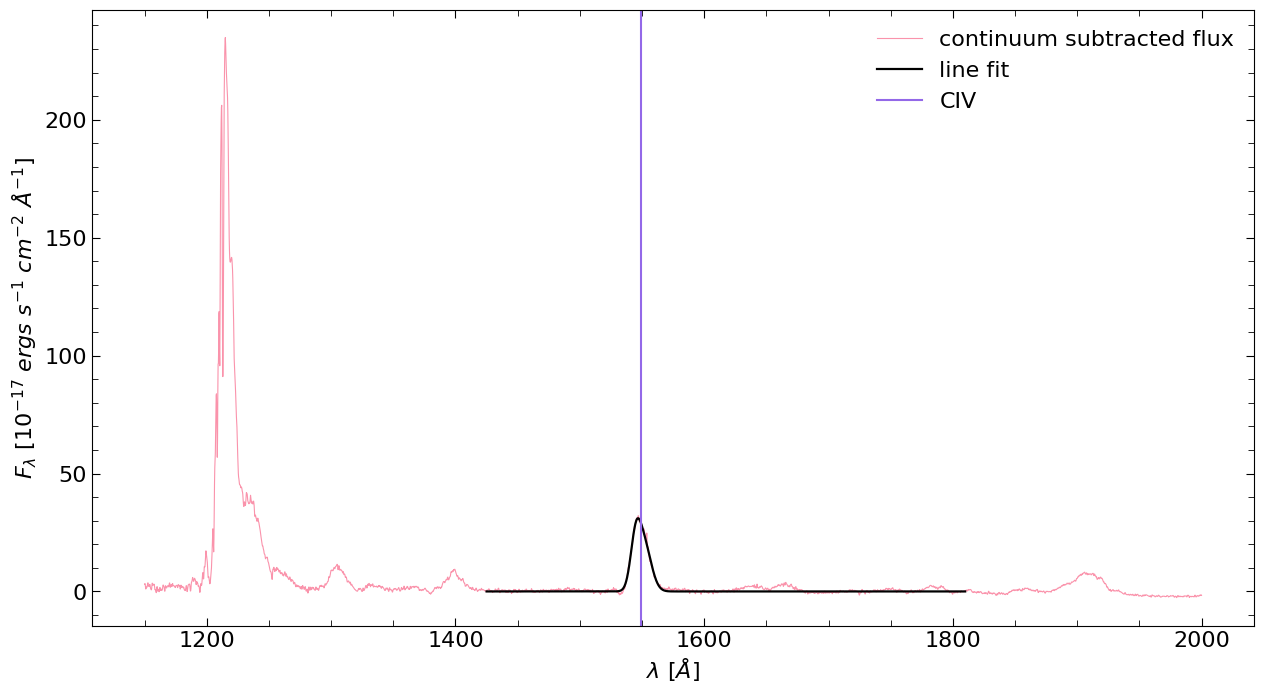


                SDSS: 083448.48+015921.1, DESI: 39627835203130381
                FWHM: 2890.305 vs 2863.092 (Hamann)
                REW: 273.925 vs 209.44 (Hamann)
                kt80: 0.368 vs 0.365 (Hamann)
                flux: 482.462 vs 549.36 (DESI)
    
---------------------------------------
---------------------------------------


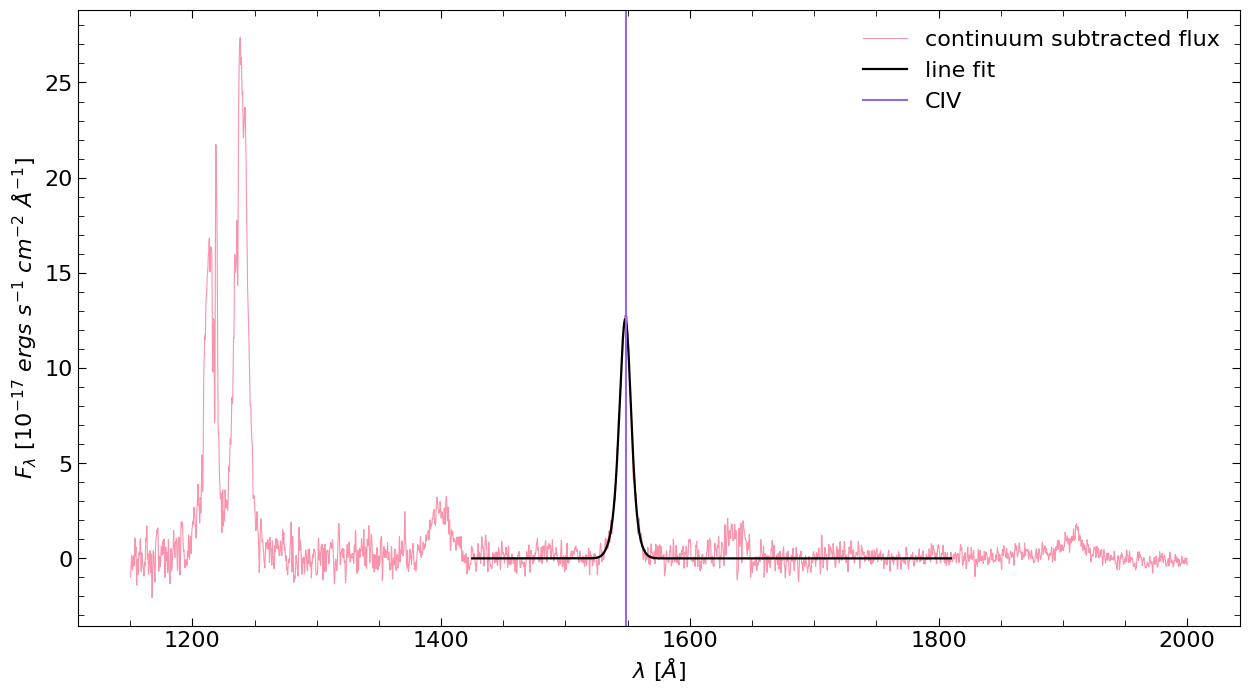


                SDSS: 131722.85+322207.5, DESI: 39628527628192559
                FWHM: 2205.081 vs 2310.771 (Hamann)
                REW: 190.869 vs 159.85 (Hamann)
                kt80: 0.339 vs 0.36 (Hamann)
                flux: 162.136 vs 169.607 (DESI)
    
---------------------------------------
---------------------------------------


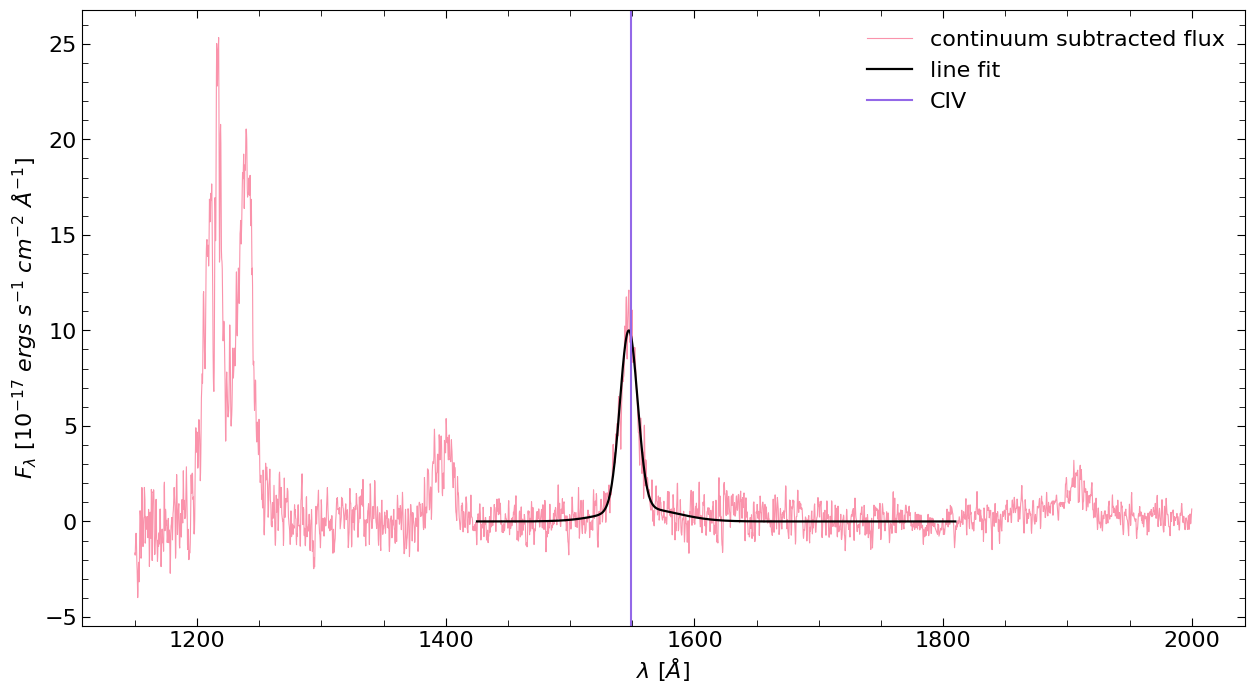


                SDSS: 130936.14+560111.3, DESI: 39633335785357580
                FWHM: 3379.65 vs 3629.606 (Hamann)
                REW: 207.735 vs 160.873 (Hamann)
                kt80: 0.356 vs 0.361 (Hamann)
                flux: 213.302 vs 224.631 (DESI)
    
---------------------------------------
---------------------------------------


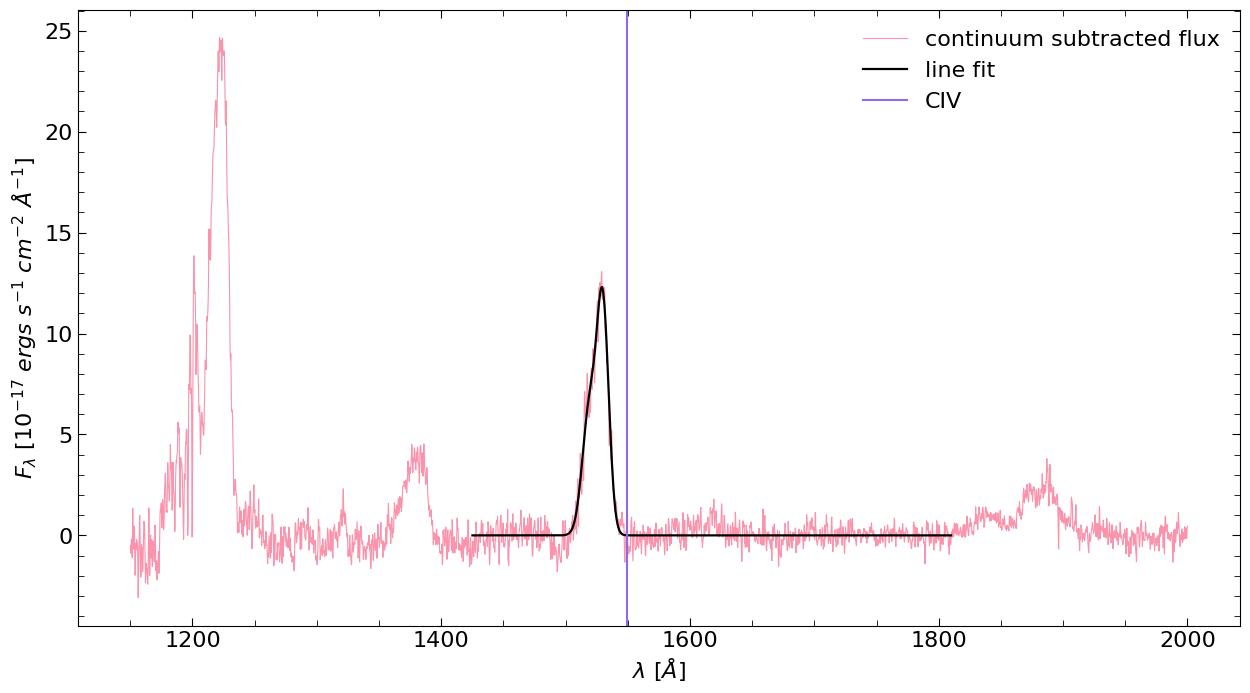


                SDSS: 002400.25+245031.9, DESI: 39628365275075274
                FWHM: 3492.423 vs 3523.282 (Hamann)
                REW: 151.302 vs 143.69 (Hamann)
                kt80: 0.303 vs 0.372 (Hamann)
                flux: 222.253 vs 25.127 (DESI)
    
---------------------------------------
---------------------------------------


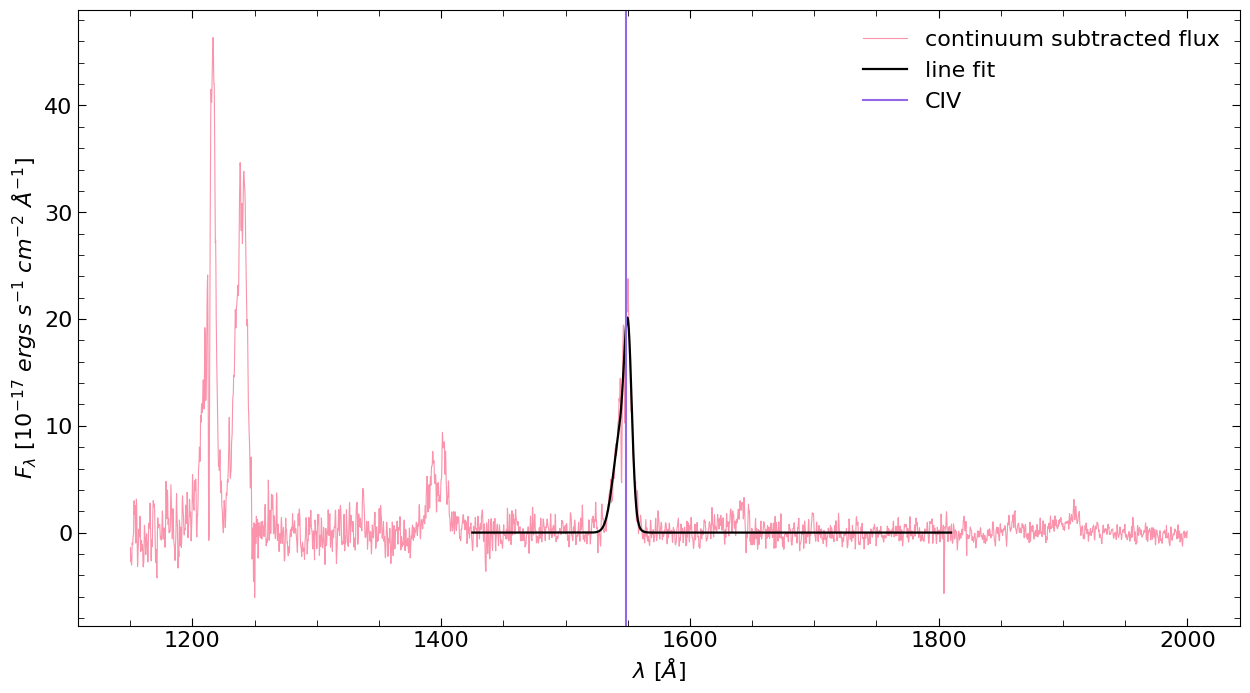


                SDSS: 134026.99+083427.2, DESI: 39627992917347231
                FWHM: 2007.984 vs 2075.846 (Hamann)
                REW: 282.755 vs 357.973 (Hamann)
                kt80: 0.264 vs 0.345 (Hamann)
                flux: 247.297 vs 251.394 (DESI)
    
---------------------------------------
---------------------------------------


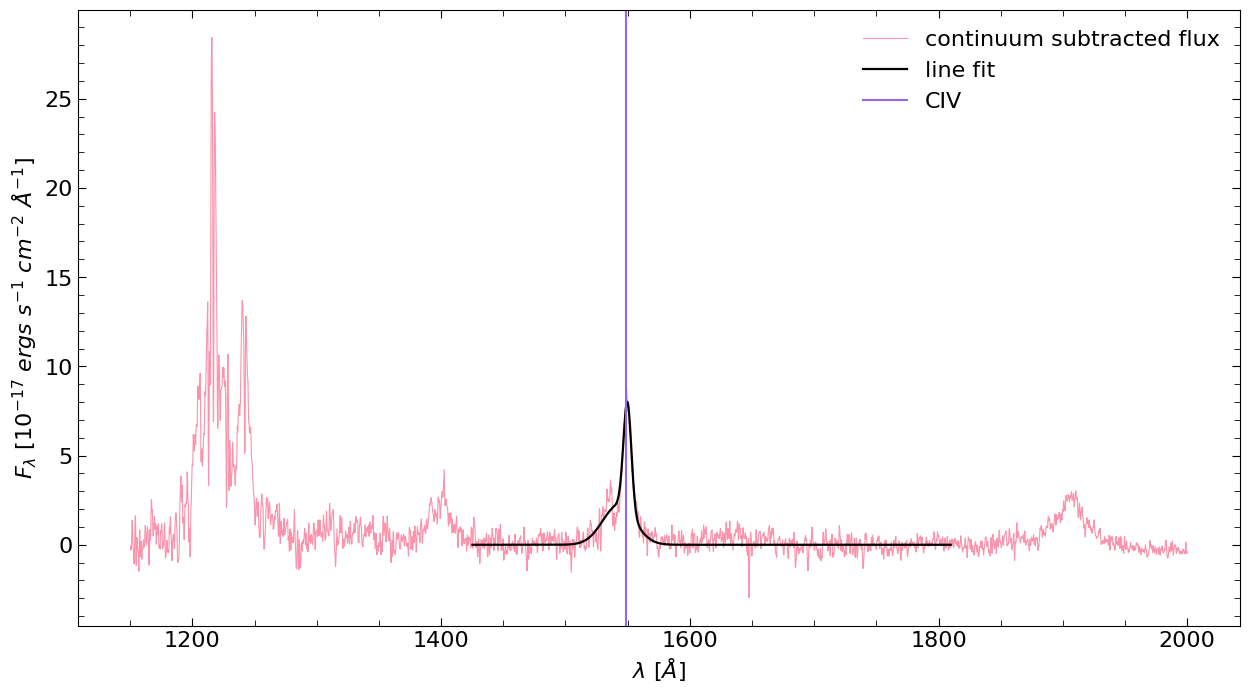


                SDSS: 134001.90+322155.9, DESI: 39628527707885249
                FWHM: 1791.771 vs 1822.703 (Hamann)
                REW: 126.744 vs 130.709 (Hamann)
                kt80: 0.2 vs 0.207 (Hamann)
                flux: 121.567 vs 92.811 (DESI)
    
---------------------------------------
---------------------------------------


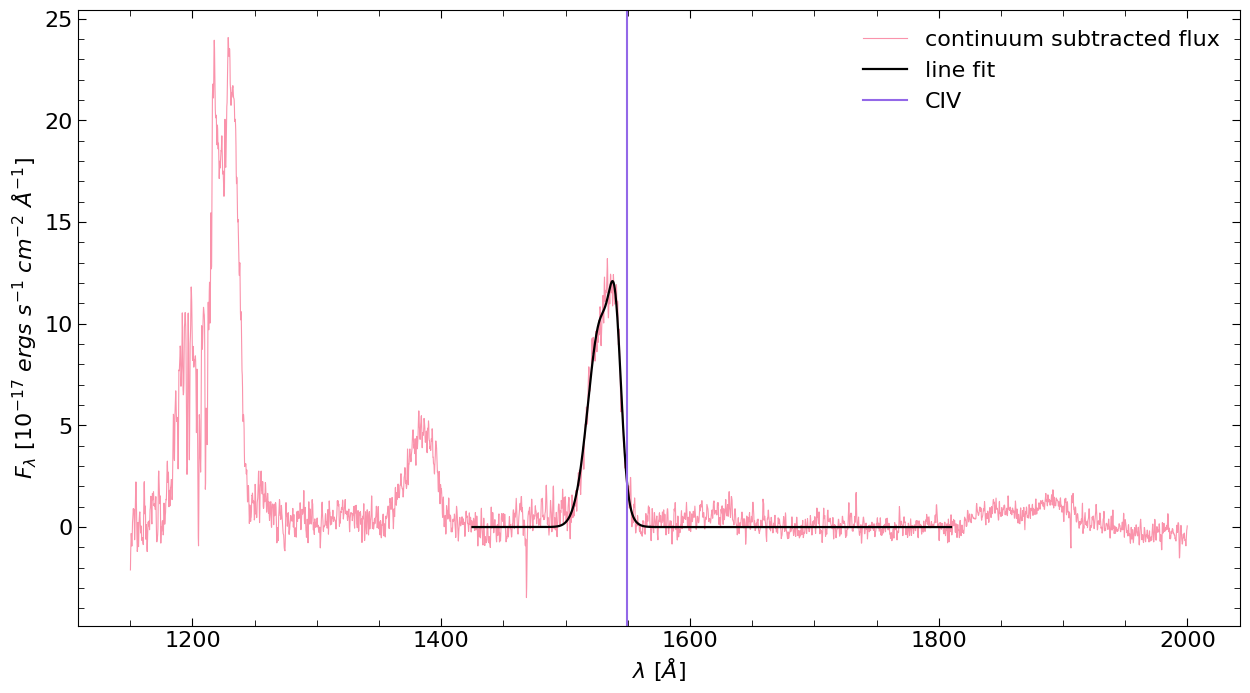


                SDSS: 104611.50+024351.6, DESI: 39627853876167561
                FWHM: 5280.654 vs 4854.269 (Hamann)
                REW: 222.72 vs 217.582 (Hamann)
                kt80: 0.443 vs 0.354 (Hamann)
                flux: 334.617 vs 255.654 (DESI)
    
---------------------------------------
---------------------------------------


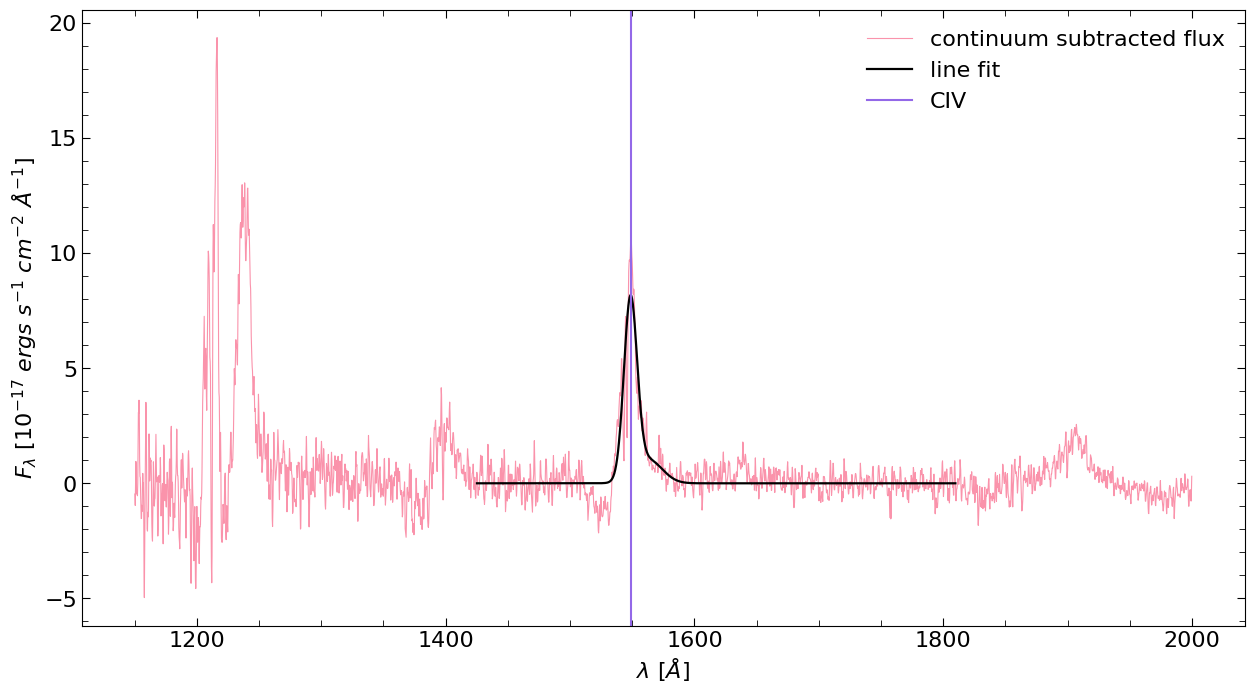


                SDSS: 093506.96-024137.7, DESI: 39627720702820887
                FWHM: 2535.267 vs 2404.04 (Hamann)
                REW: 87.087 vs 119.496 (Hamann)
                kt80: 0.344 vs 0.249 (Hamann)
                flux: 132.538 vs 147.833 (DESI)
    
---------------------------------------
---------------------------------------


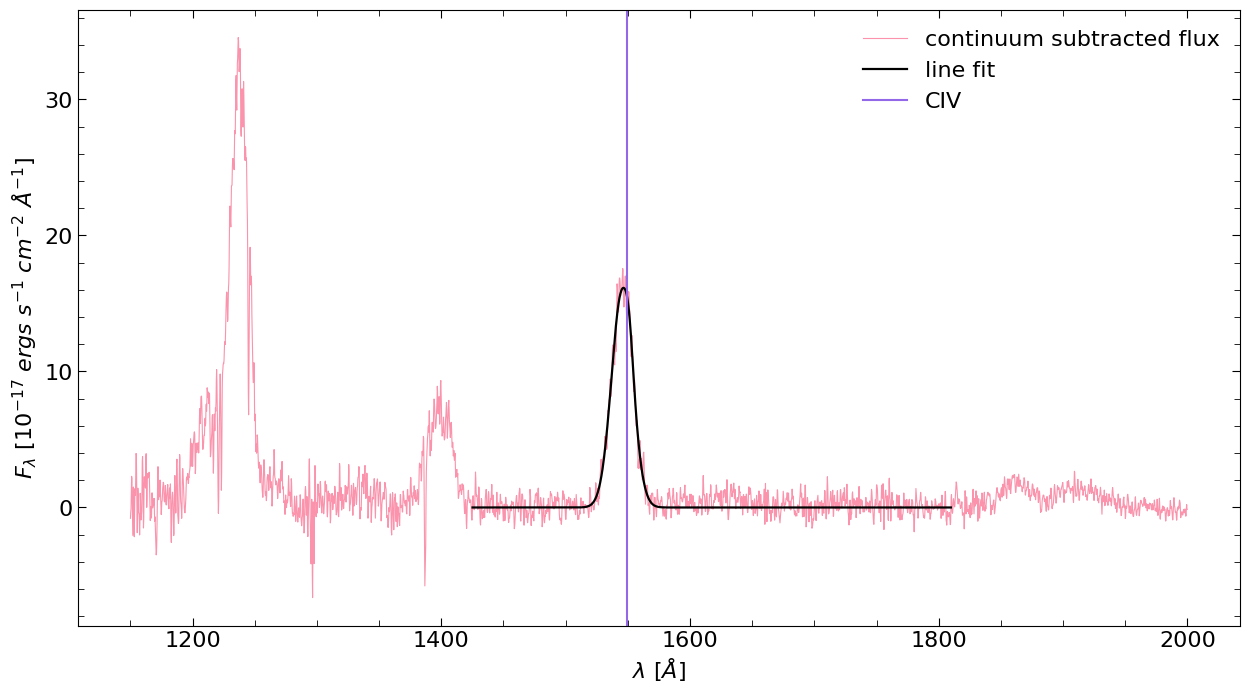


                SDSS: 232326.17-010033.1, DESI: 39627766454292268
                FWHM: 3906.027 vs 3989.27 (Hamann)
                REW: 354.26 vs 255.993 (Hamann)
                kt80: 0.408 vs 0.371 (Hamann)
                flux: 348.676 vs 374.365 (DESI)
    
---------------------------------------
---------------------------------------


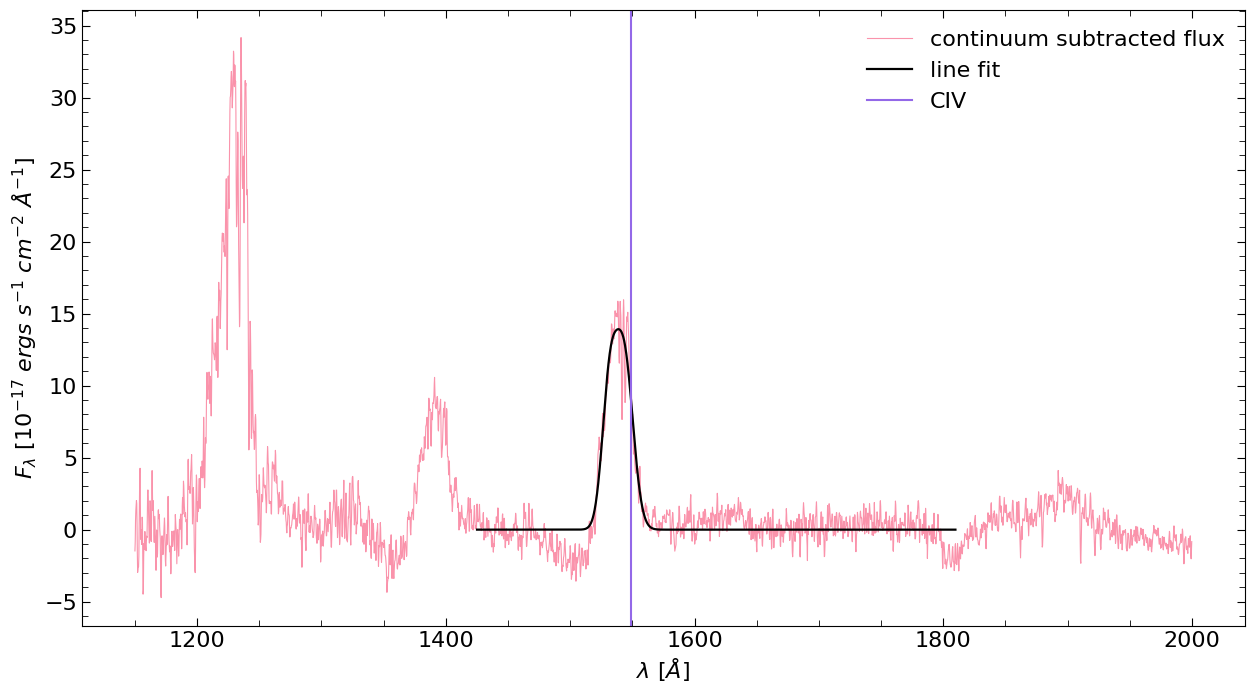


                SDSS: 103146.53+290324.1, DESI: 39628459336535305
                FWHM: 4769.684 vs 4363.774 (Hamann)
                REW: 91.487 vs 120.767 (Hamann)
                kt80: 0.483 vs 0.372 (Hamann)
                flux: 348.98 vs 321.487 (DESI)
    
---------------------------------------
---------------------------------------


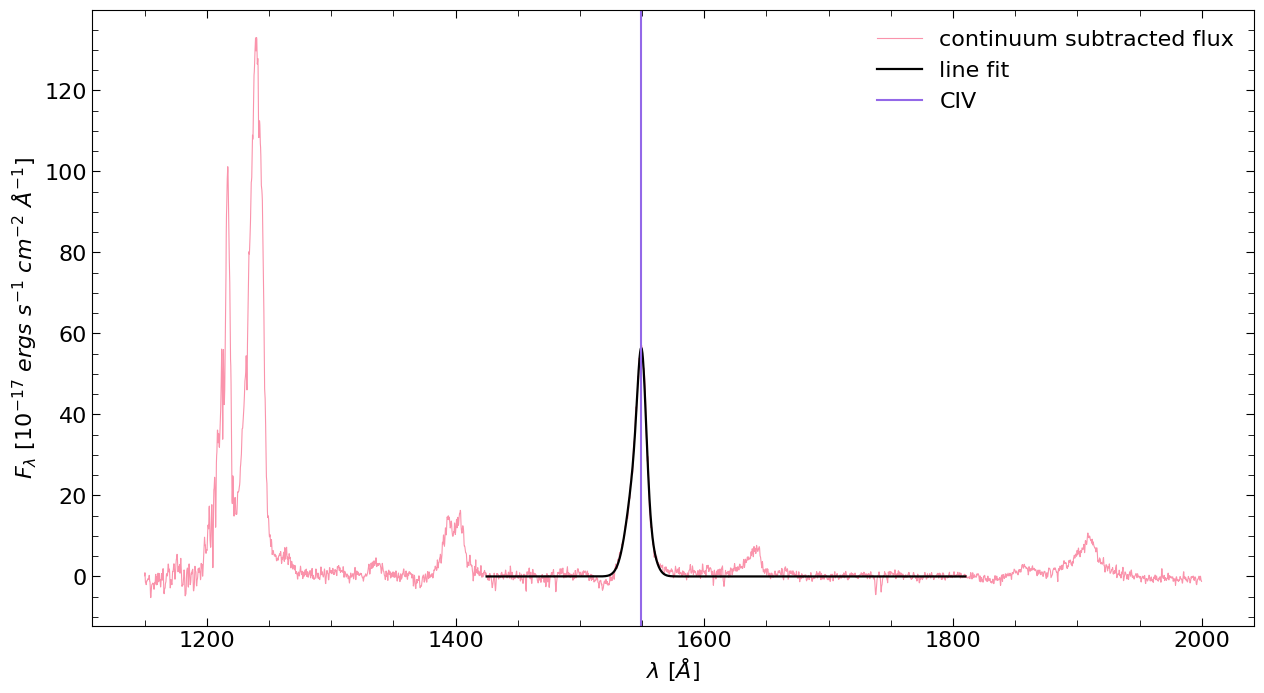


                SDSS: 165202.64+172852.3, DESI: 39628205555974657
                FWHM: 2290.59 vs 2403.322 (Hamann)
                REW: 187.792 vs 124.521 (Hamann)
                kt80: 0.282 vs 0.329 (Hamann)
                flux: 797.7 vs 905.182 (DESI)
    
---------------------------------------
---------------------------------------


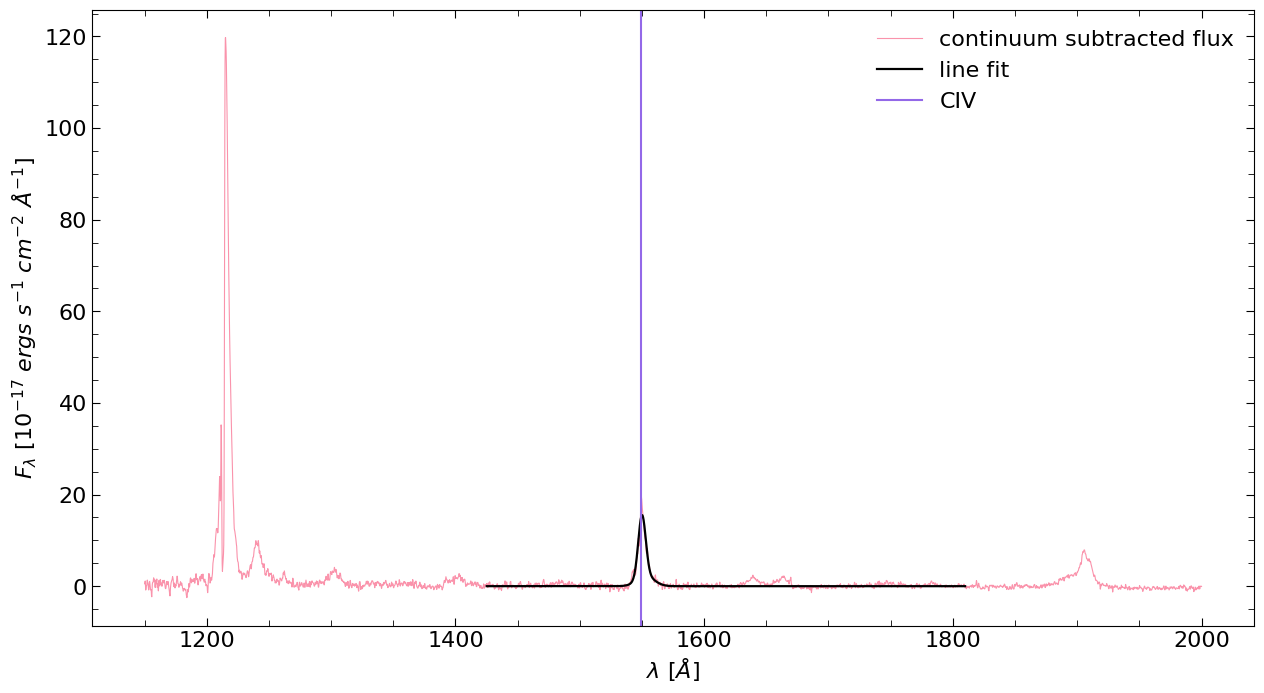


                SDSS: 122000.68+064045.3, DESI: 39627950634570587
                FWHM: 1480.923 vs 1047.131 (Hamann)
                REW: 137.205 vs 112.877 (Hamann)
                kt80: 0.346 vs 0.151 (Hamann)
                flux: 139.969 vs 137.558 (DESI)
    
---------------------------------------
---------------------------------------


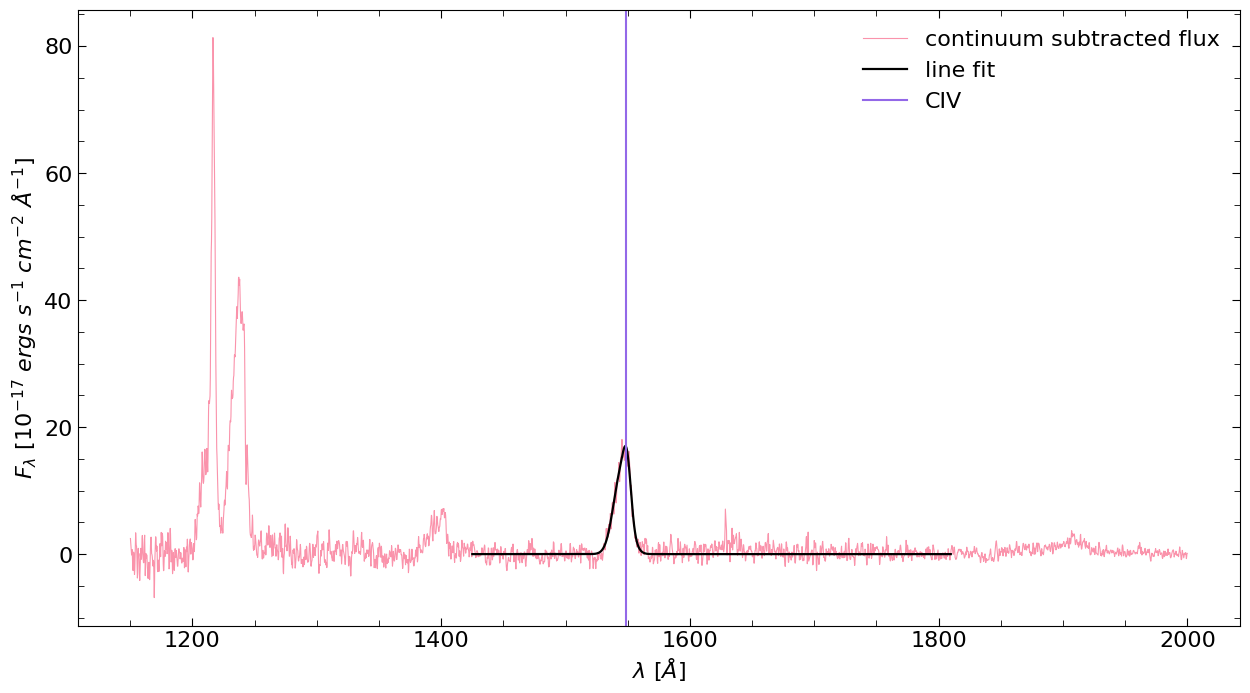


                SDSS: 121704.70+023417.1, DESI: 39627848218050974
                FWHM: 2729.512 vs 2603.968 (Hamann)
                REW: 206.825 vs 180.897 (Hamann)
                kt80: 0.344 vs 0.369 (Hamann)
                flux: 251.525 vs 281.832 (DESI)
    
---------------------------------------
---------------------------------------


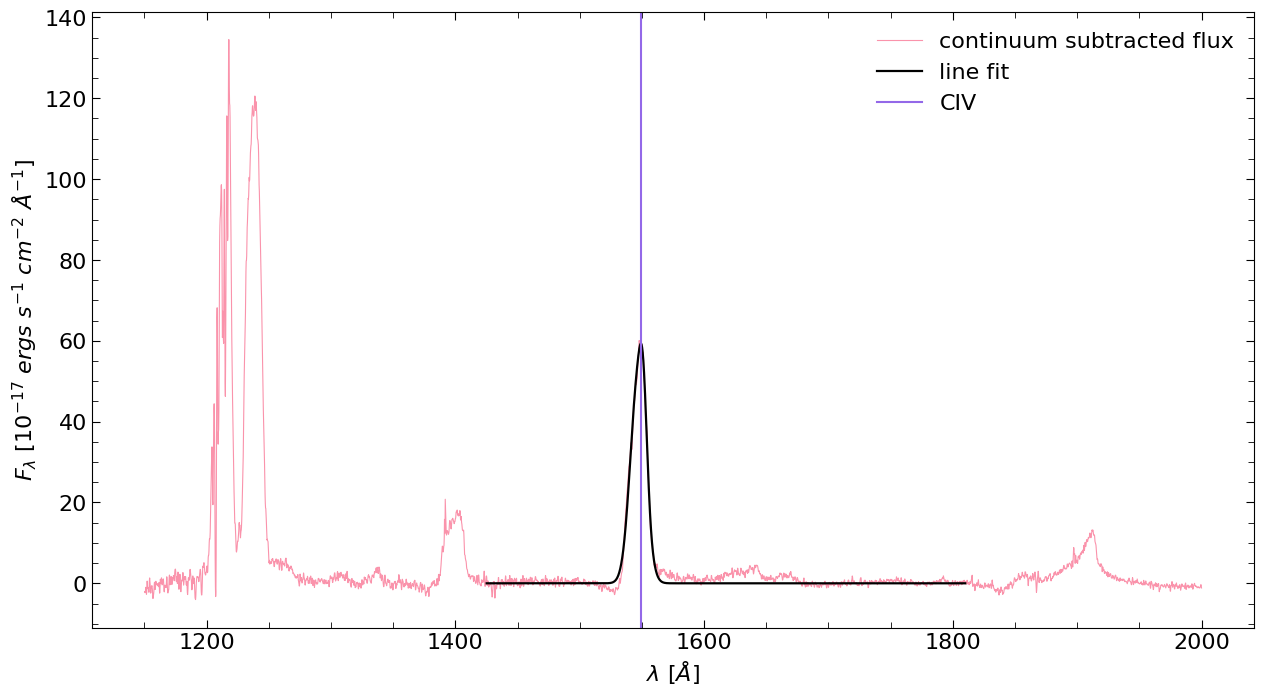


                SDSS: 131047.78+322518.3, DESI: 39632930762395245
                FWHM: 2758.096 vs 2793.839 (Hamann)
                REW: 250.427 vs 226.394 (Hamann)
                kt80: 0.376 vs 0.367 (Hamann)
                flux: 886.359 vs 925.713 (DESI)
    
---------------------------------------
---------------------------------------


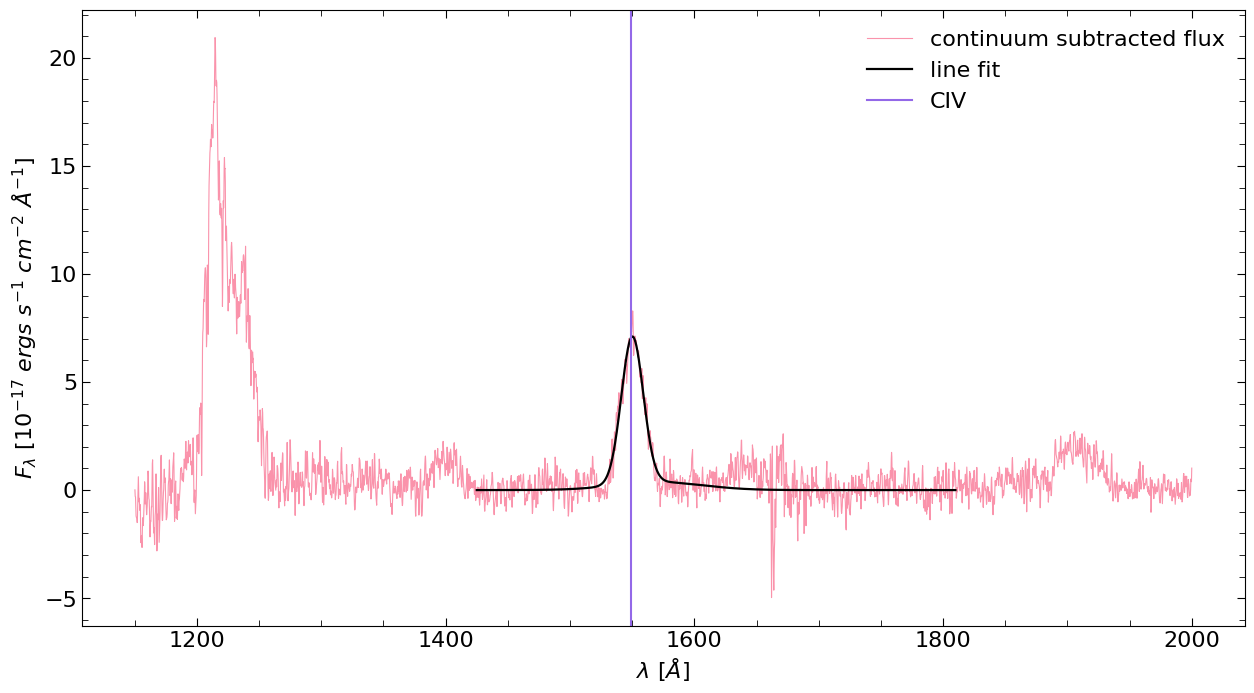


                SDSS: 221524.00-005643.8, DESI: 39627766169079016
                FWHM: 4128.414 vs 4280.102 (Hamann)
                REW: 228.674 vs 153.336 (Hamann)
                kt80: 0.361 vs 0.366 (Hamann)
                flux: 188.797 vs 272.195 (DESI)
    
---------------------------------------
---------------------------------------


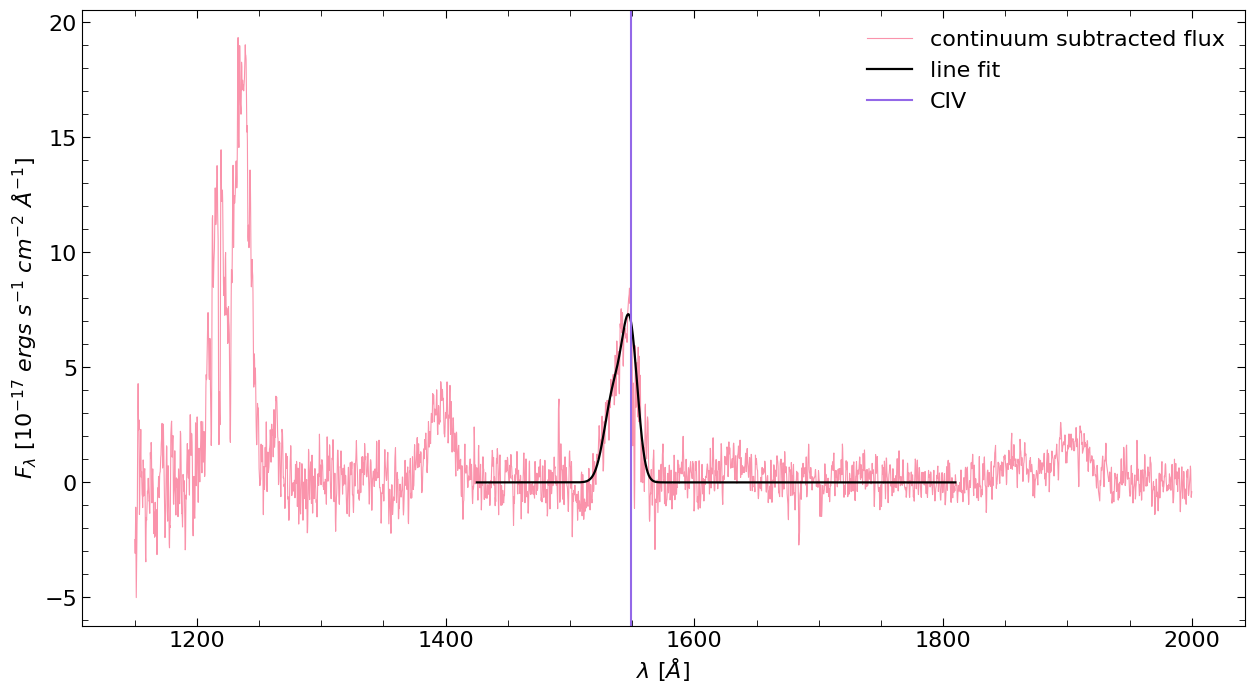


                SDSS: 134450.51+140139.2, DESI: 39628123335037135
                FWHM: 4419.137 vs 4487.034 (Hamann)
                REW: 151.25 vs 132.41 (Hamann)
                kt80: 0.318 vs 0.372 (Hamann)
                flux: 158.952 vs 179.483 (DESI)
    
---------------------------------------
---------------------------------------


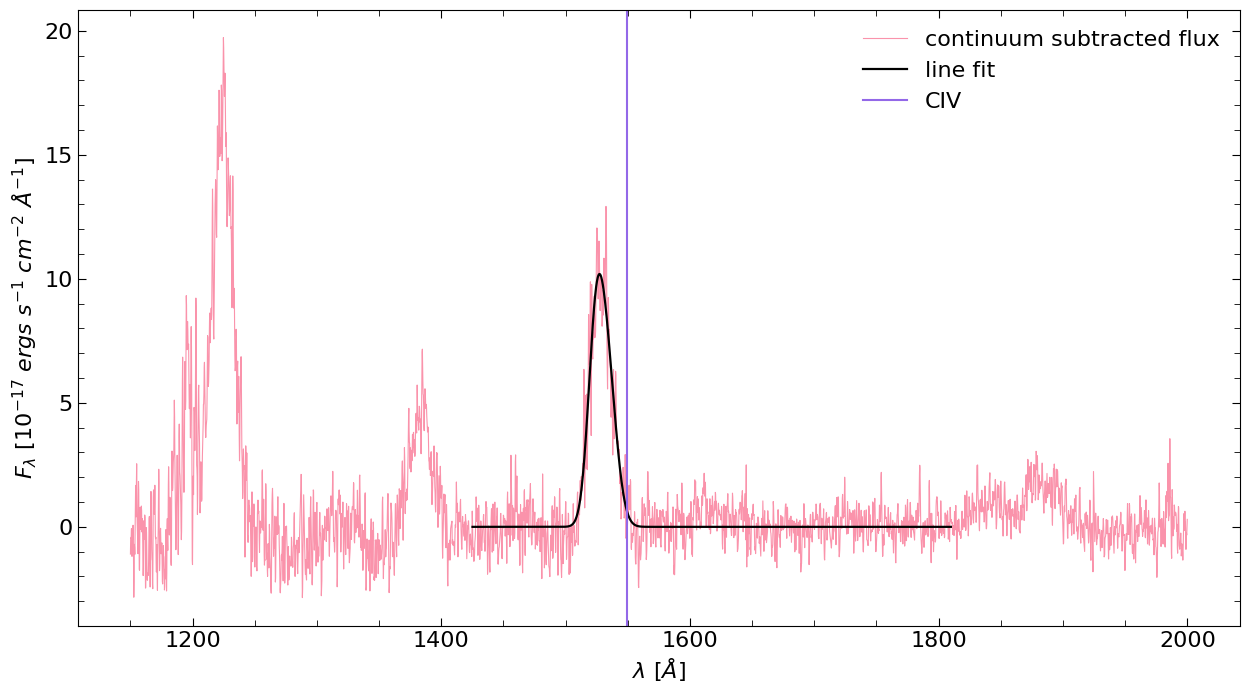


                SDSS: 153107.14+105825.8, DESI: 39628052950420499
                FWHM: 3975.132 vs 3936.554 (Hamann)
                REW: 156.551 vs 151.904 (Hamann)
                kt80: 0.382 vs 0.372 (Hamann)
                flux: 220.152 vs 1.086 (DESI)
    
---------------------------------------
---------------------------------------


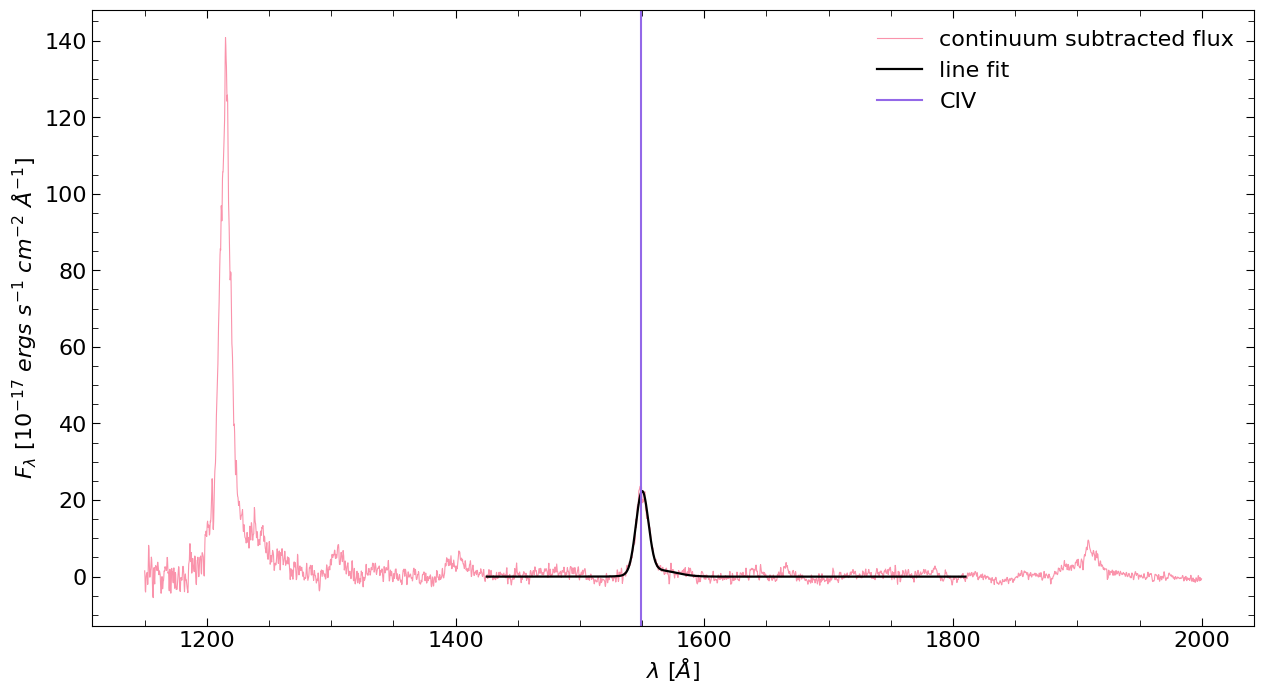


                SDSS: 104718.35+484433.8, DESI: 39633228125965823
                FWHM: 2368.608 vs 2521.46 (Hamann)
                REW: 175.006 vs 158.03 (Hamann)
                kt80: 0.358 vs 0.361 (Hamann)
                flux: 329.263 vs 310.697 (DESI)
    
---------------------------------------
---------------------------------------


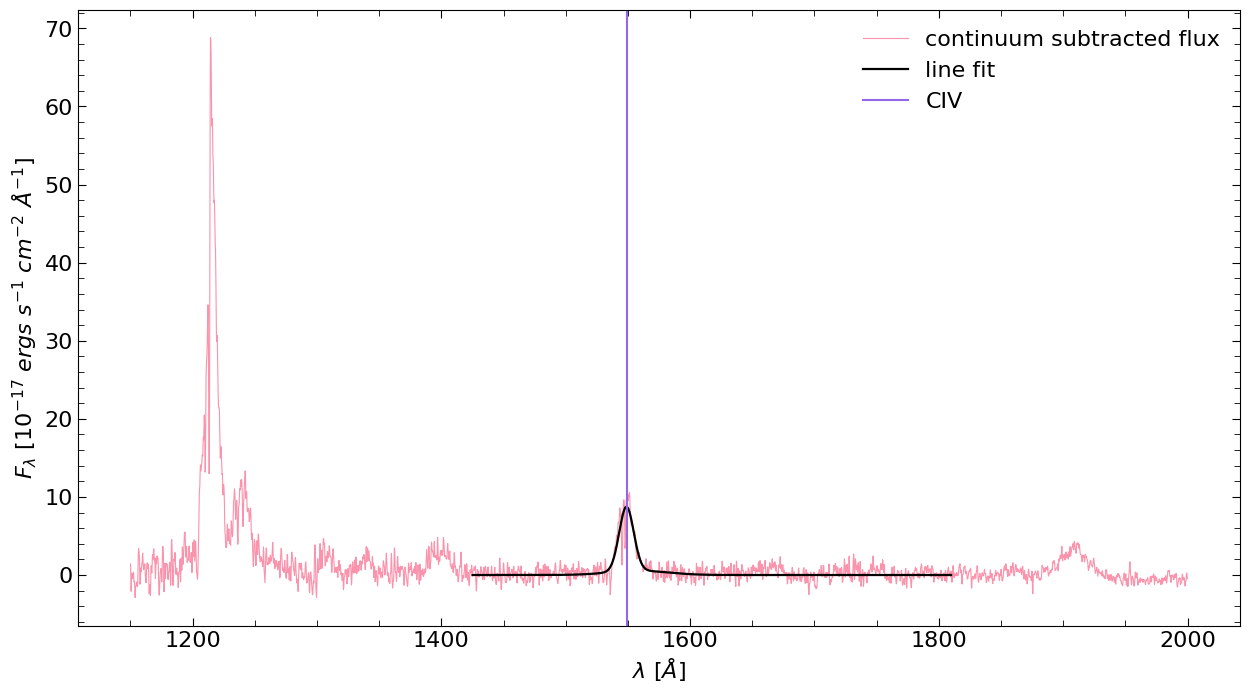


                SDSS: 020932.15+312202.7, DESI: 39628504643403849
                FWHM: 2769.025 vs 2180.064 (Hamann)
                REW: 140.638 vs 107.677 (Hamann)
                kt80: 0.358 vs 0.345 (Hamann)
                flux: 149.494 vs 160.998 (DESI)
    
---------------------------------------
---------------------------------------


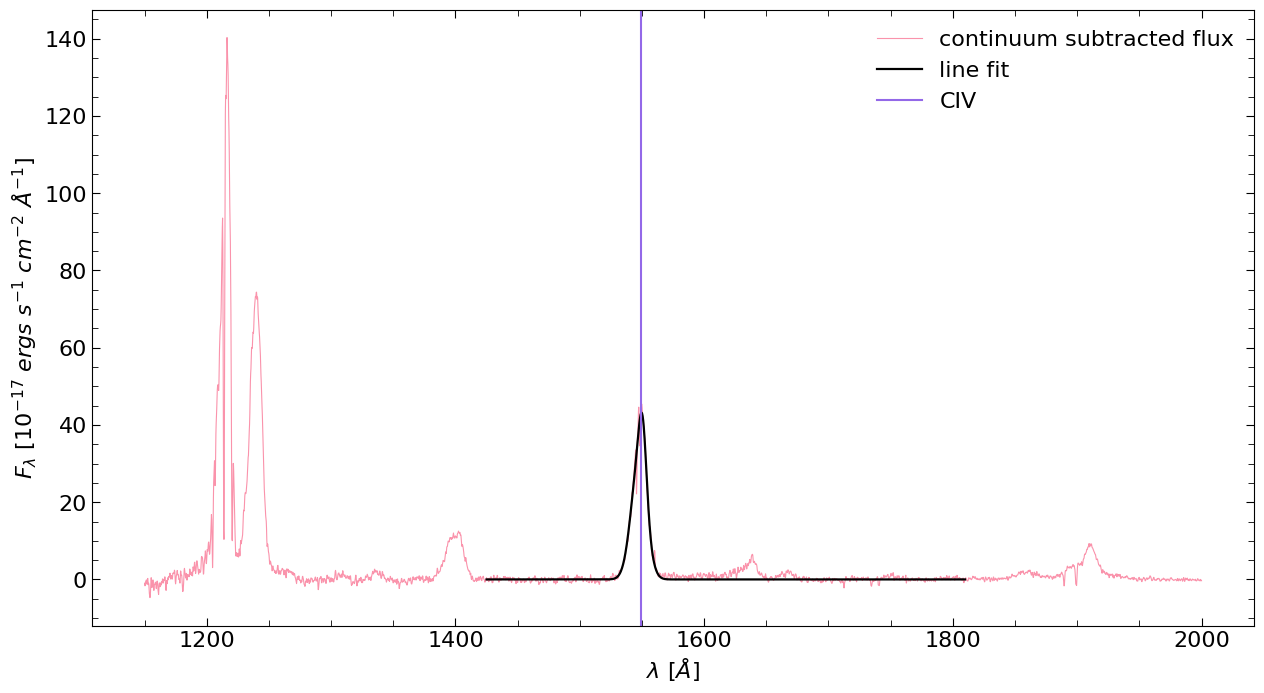


                SDSS: 082653.42+054247.3, DESI: 39627925623935704
                FWHM: 2386.091 vs 2433.822 (Hamann)
                REW: 232.011 vs 204.619 (Hamann)
                kt80: 0.313 vs 0.358 (Hamann)
                flux: 587.208 vs 624.157 (DESI)
    
---------------------------------------
---------------------------------------


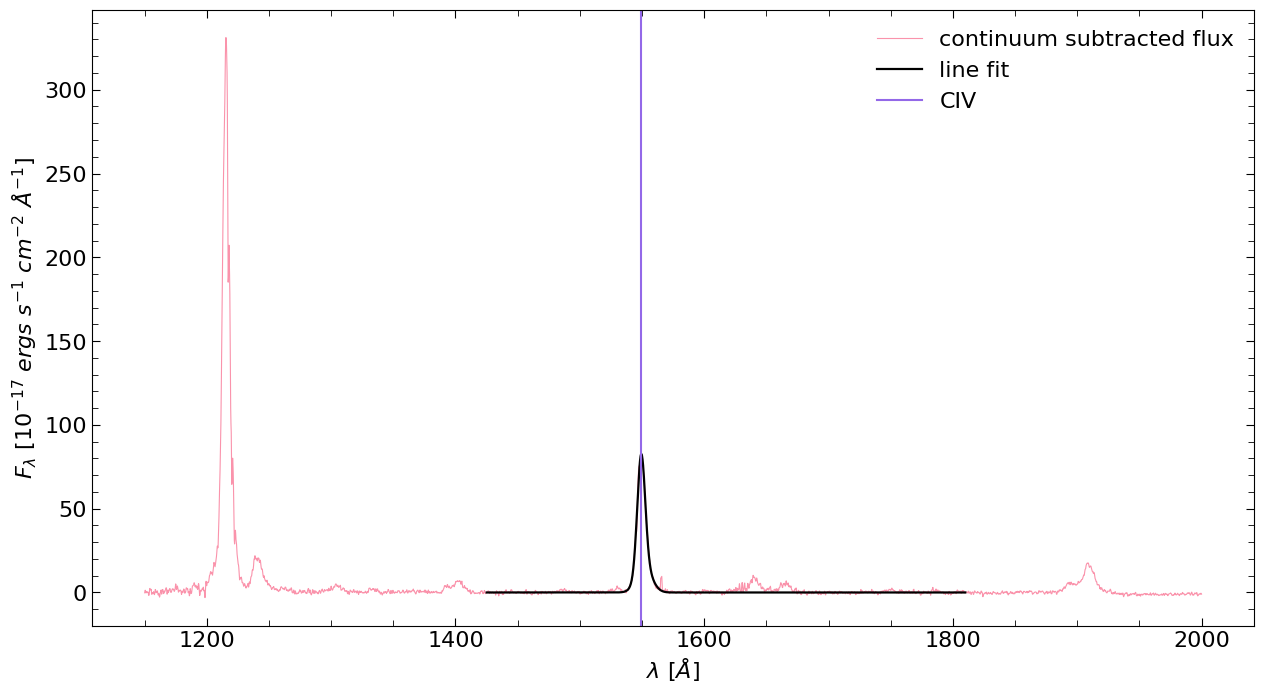


                SDSS: 232828.47+044346.8, DESI: 39627905315113841
                FWHM: 1576.024 vs 1583.693 (Hamann)
                REW: 408.266 vs 358.596 (Hamann)
                kt80: 0.346 vs 0.352 (Hamann)
                flux: 773.578 vs 882.327 (DESI)
    
---------------------------------------
---------------------------------------


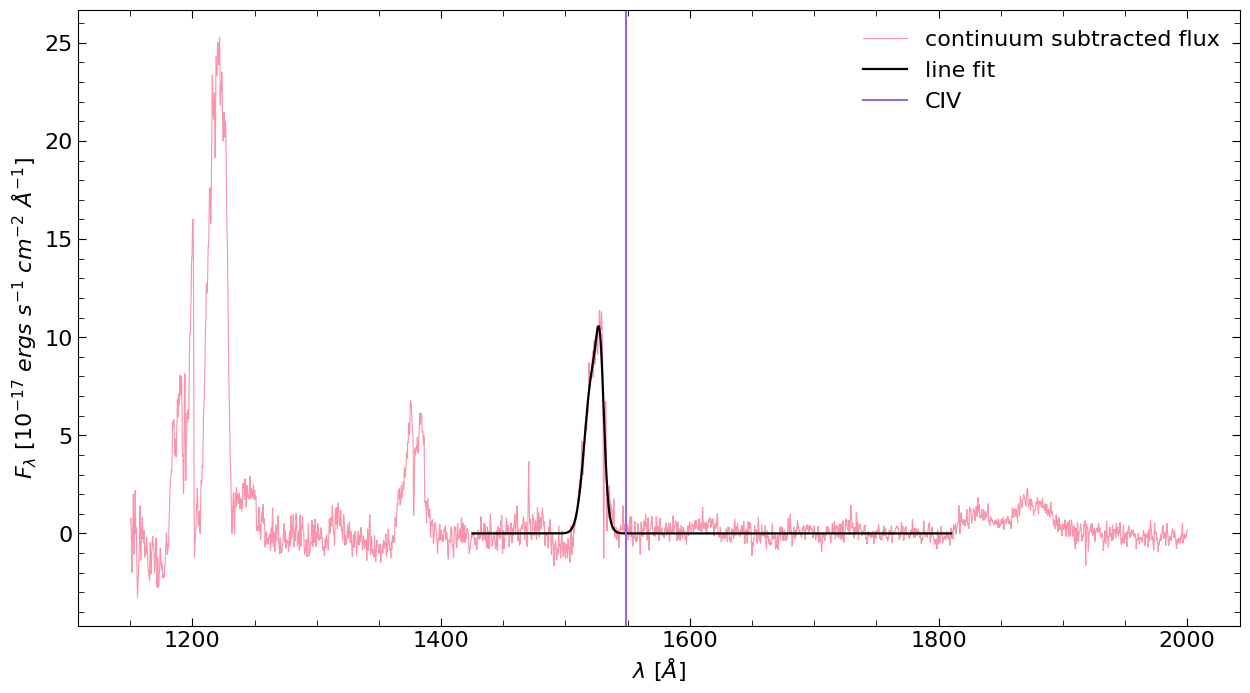


                SDSS: 154831.92+311951.4, DESI: 39628507583615618
                FWHM: 2966.154 vs 3050.048 (Hamann)
                REW: 126.097 vs 127.184 (Hamann)
                kt80: 0.354 vs 0.372 (Hamann)
                flux: 163.411 vs 3.494 (DESI)
    
---------------------------------------
---------------------------------------


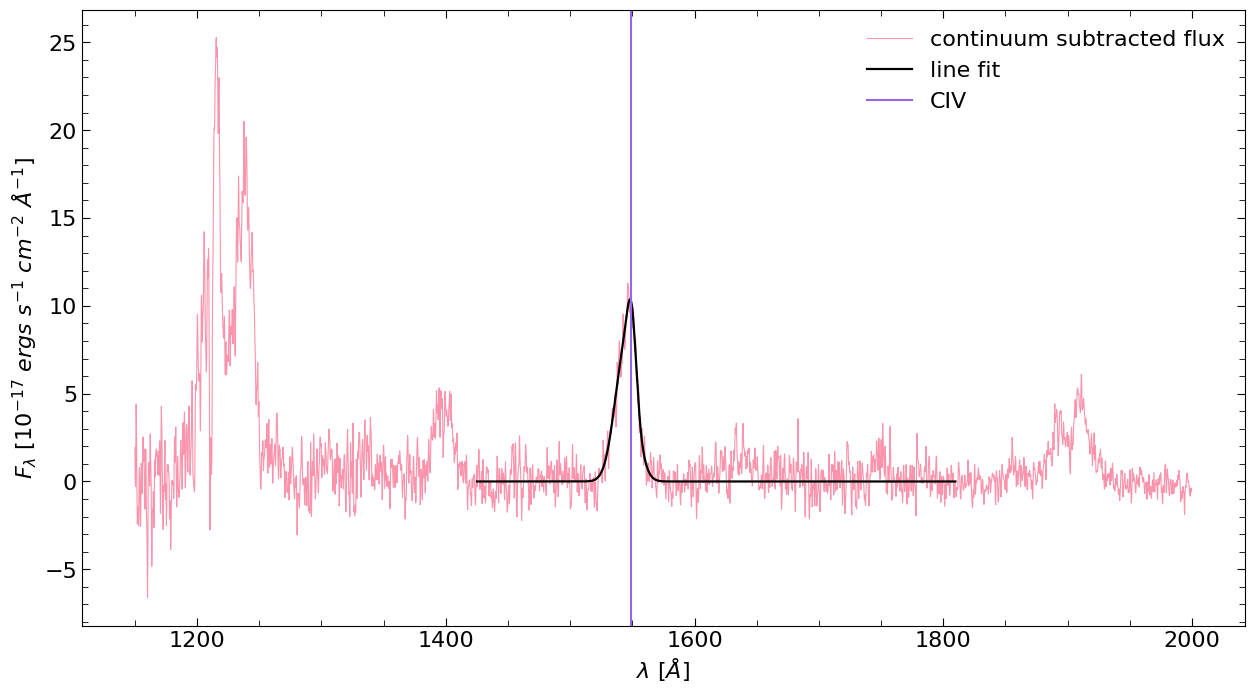


                SDSS: 080547.66+454159.0, DESI: 39633178285048118
                FWHM: 3324.506 vs 2667.071 (Hamann)
                REW: 162.463 vs 108.69 (Hamann)
                kt80: 0.308 vs 0.211 (Hamann)
                flux: 190.847 vs 242.485 (DESI)
    
---------------------------------------
---------------------------------------


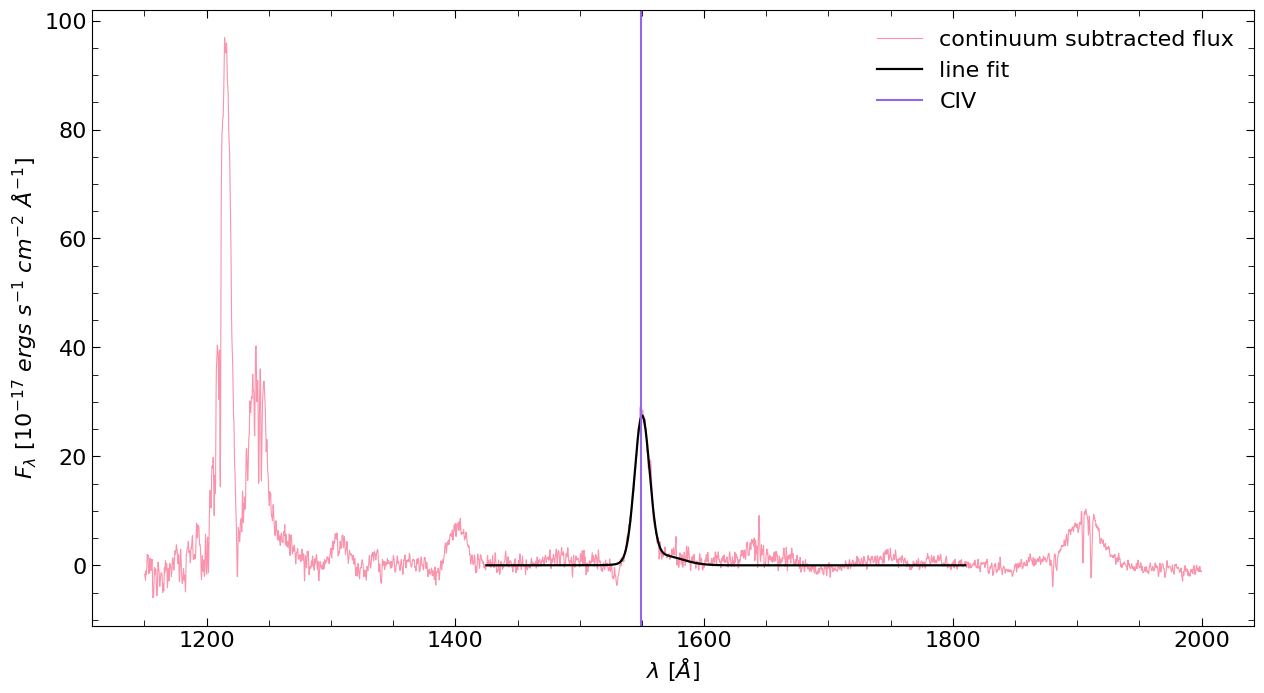


                SDSS: 014111.13-031852.5, DESI: 39627706643513715
                FWHM: 2811.527 vs 2985.648 (Hamann)
                REW: 122.774 vs 101.008 (Hamann)
                kt80: 0.36 vs 0.372 (Hamann)
                flux: 469.44 vs 436.53 (DESI)
    
---------------------------------------
---------------------------------------


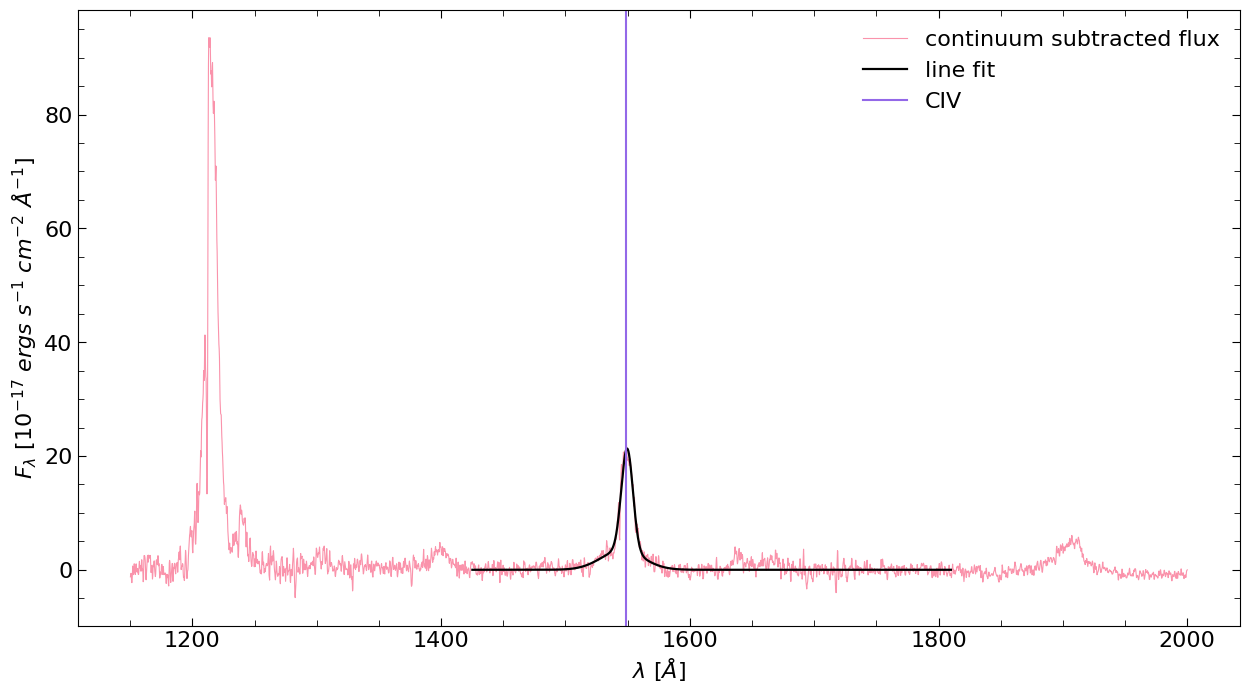


                SDSS: 000746.19+122223.9, DESI: 39628078770555722
                FWHM: 2370.819 vs 2432.83 (Hamann)
                REW: 237.81 vs 219.634 (Hamann)
                kt80: 0.325 vs 0.284 (Hamann)
                flux: 349.193 vs 382.848 (DESI)
    
---------------------------------------
---------------------------------------


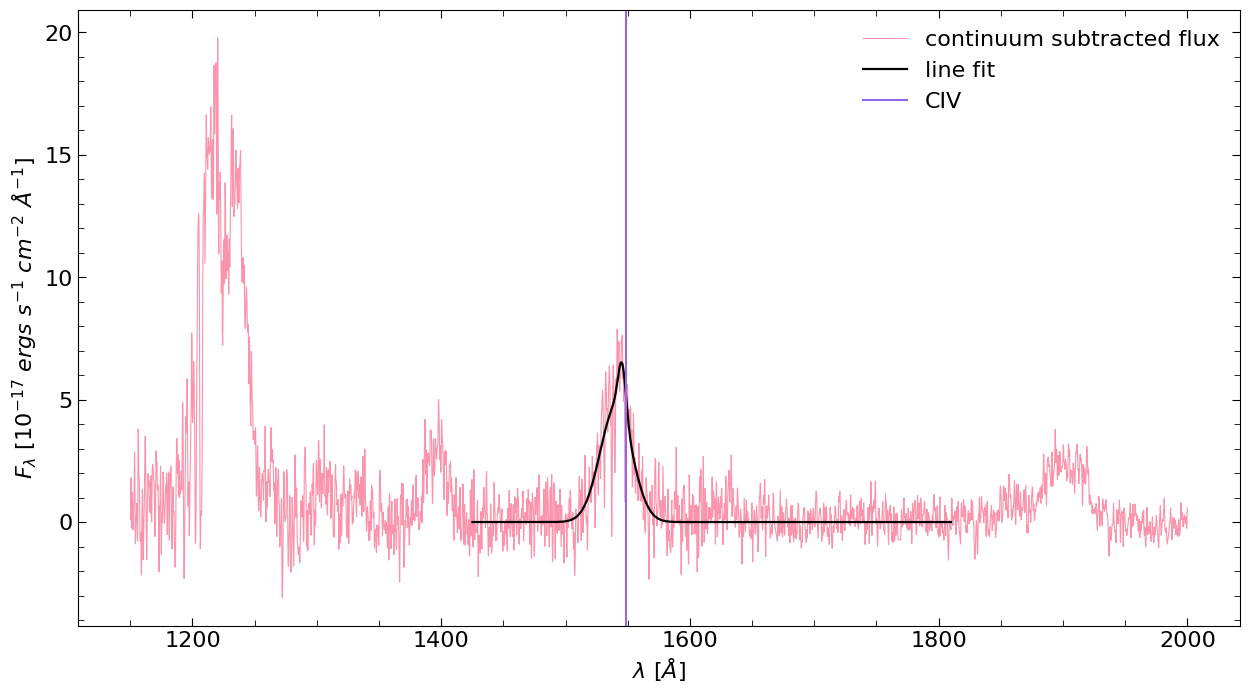


                SDSS: 085451.11+173009.1, DESI: 39628203643371939
                FWHM: 4420.339 vs 4199.357 (Hamann)
                REW: 177.921 vs 120.014 (Hamann)
                kt80: 0.206 vs 0.37 (Hamann)
                flux: 165.173 vs 223.233 (DESI)
    
---------------------------------------
---------------------------------------


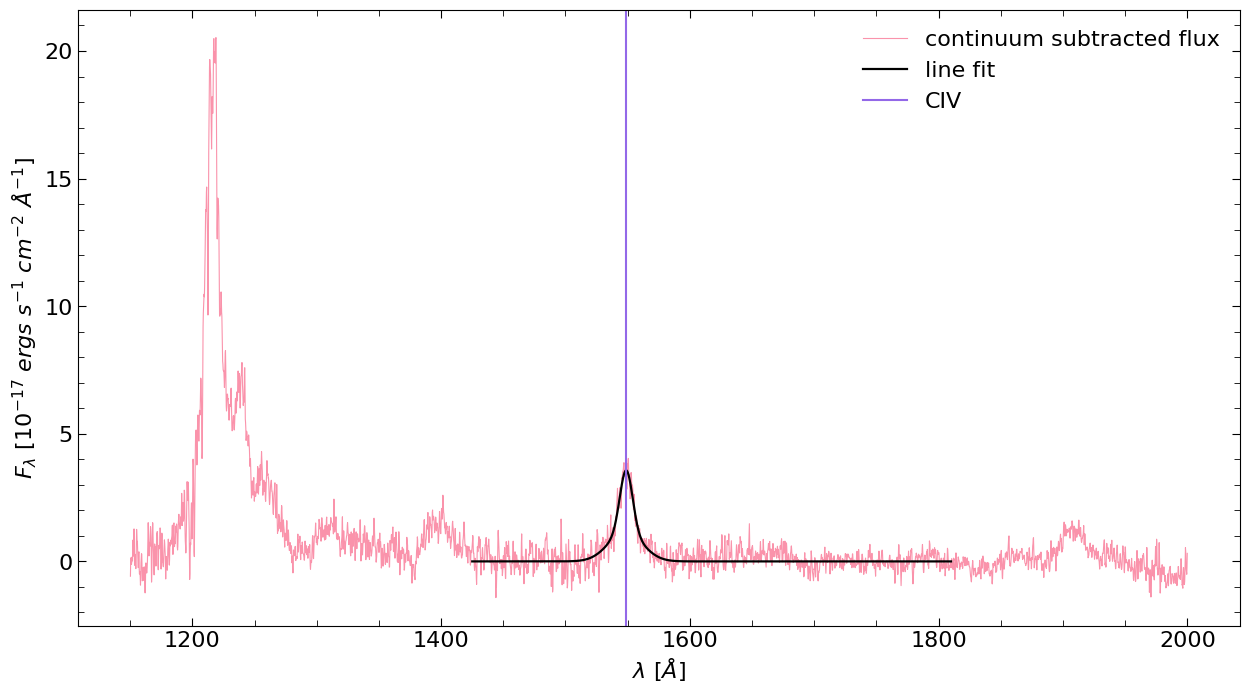


                SDSS: 102447.32-013633.8, DESI: 39627751107334558
                FWHM: 2911.659 vs 2843.202 (Hamann)
                REW: 88.934 vs 192.349 (Hamann)
                kt80: 0.286 vs 0.148 (Hamann)
                flux: 69.416 vs 90.278 (DESI)
    
---------------------------------------
---------------------------------------


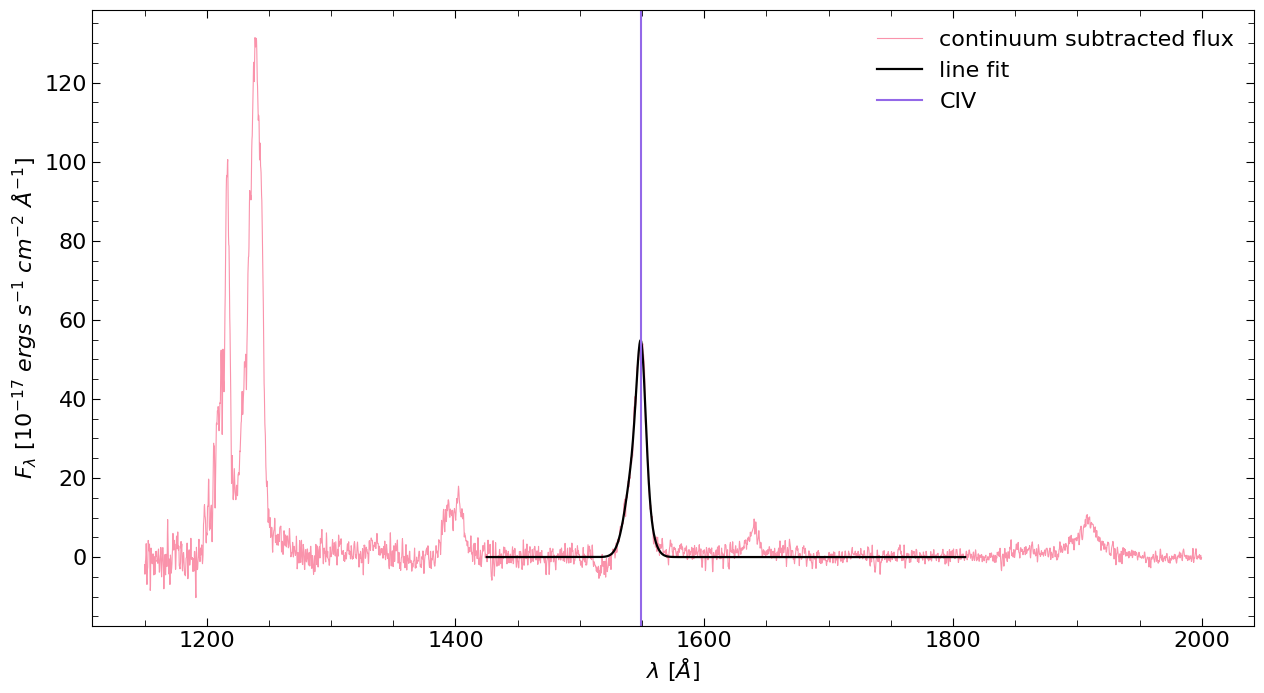


                SDSS: 165202.64+172852.3, DESI: 39628205555974657
                FWHM: 2310.77 vs 2403.322 (Hamann)
                REW: 197.07 vs 124.521 (Hamann)
                kt80: 0.283 vs 0.329 (Hamann)
                flux: 781.957 vs 905.182 (DESI)
    


In [13]:
for i in range(len(spectra_df)):
    if spectra_df["specid"][i] in valid_idxs:
        print("---------------------------------------\n---------------------------------------")
        sanity_tests(i)